In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

#### Polynomial Regression: A Simple Explanation

Polynomial regression is an extension of linear regression that allows you to model non-linear relationships between the independent variables (features) and the dependent variable (target). Instead of fitting a straight line to the data, polynomial regression fits a curved line (a polynomial of degree n).

How It Works
1. The Idea


In linear regression, the relationship between X and y is modeled as:

y = β₀ + β₁X + ε

(a straight line).


In polynomial regression, you add polynomial terms (e.g., X2X^2X2, X3X^3X3) to capture non-linear patterns:

y = β₀ + β₁X + β₂X² + β₃X³ + ... + βₙXⁿ + ε


This allows the model to fit curves, parabolas, or higher-order polynomials to the data.



Example: Quadratic Polynomial (Degree 2)
If you use a 2nd-degree polynomial, the equation becomes:

y = β₀ + β₁X + β₂X² + ε
This can model U-shaped or inverted-U-shaped relationships (e.g., a parabola).

3. Example: Cubic Polynomial (Degree 3)
If you use a 3rd-degree polynomial, the equation becomes:

y = β₀ + β₁X + β₂X² + β₃X³ + ε
This can model S-shaped curves or more complex non-linear patterns.


### When to Use Polynomial Regression

'''
✅ Use it when:


The relationship between X and y is non-linear (e.g., growth slows down after a certain point, or accelerates).
A linear regression model underfits the data (high bias).
You want to capture more complex patterns without switching 
to non-parametric models (e.g., decision trees).


❌ Avoid it when:

The relationship is truly linear (polynomial regression will overcomplicate the model).
The dataset is small (high-degree polynomials can overfit).
The polynomial degree is too high (leads to overfitting).
'''

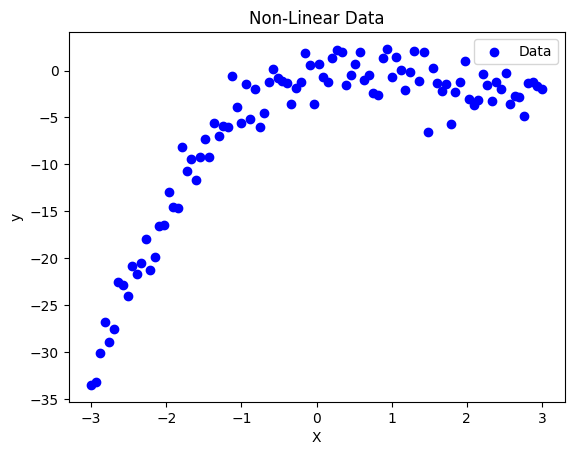

In [44]:
# Generate non-linear data (e.g., y = x^3 + noise)
np.random.seed(42)
X = np.linspace(-3, 3, 100)  # 100 points between -3 and 3
y = 0.5 * X**3 - 2 * X**2 + X + np.random.normal(0, 2, 100) 
# True relationship: y = 0.5x³ - 2x² + x + noise

# Plot the data
plt.scatter(X, y, color='blue', label='Data')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Non-Linear Data')
plt.legend()
plt.show()

In [45]:
## splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

### Simple Linear Regression

In [46]:
model = LinearRegression()
model.fit(X_train.reshape(-1, 1), y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [47]:
y_pred = model.predict(X_test.reshape(-1, 1))
score = r2_score(y_test, y_pred)
print(f"R² Score: {score:.4f}")

R² Score: 0.5818


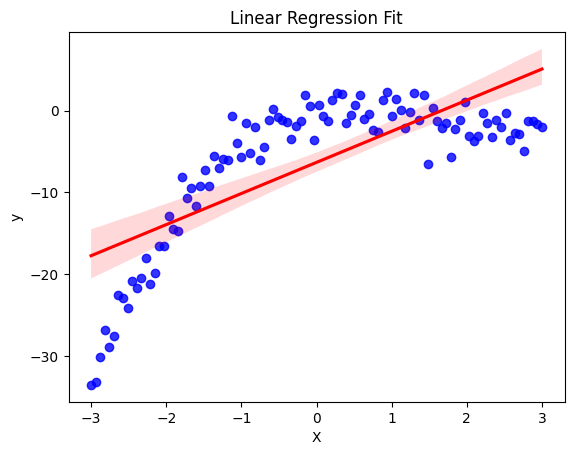

In [48]:
## visuaize this model
sns.regplot(x=X, y=y, scatter_kws={'color': 'blue'}, line_kws={'color': 'red'})
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression Fit')
plt.show() 

### Polynomial regression

In [49]:
## polynomial transformation
from sklearn.preprocessing import PolynomialFeatures

In [50]:
poly = PolynomialFeatures(degree=2, include_bias=True)
X_train_poly = poly.fit_transform(X_train.reshape(-1, 1))
X_test_poly = poly.transform(X_test.reshape(-1, 1))

In [51]:
X_train_poly[:5]  # Show the first 5 transformed samples

array([[ 1.        ,  0.33333333,  0.11111111],
       [ 1.        ,  2.33333333,  5.44444444],
       [ 1.        , -1.42424242,  2.02846648],
       [ 1.        , -0.45454545,  0.20661157],
       [ 1.        ,  1.18181818,  1.39669421]])

In [52]:
X_test_poly[:5]  # Show the first 5 transformed samples in the test set

array([[ 1.        ,  2.03030303,  4.12213039],
       [ 1.        ,  0.21212121,  0.04499541],
       [ 1.        ,  1.24242424,  1.543618  ],
       [ 1.        , -0.27272727,  0.07438017],
       [ 1.        , -0.33333333,  0.11111111]])

In [53]:
## applying the linear regression model to the polynomial features
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)  


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [54]:
y_poly_pred = model_poly.predict(X_test_poly)
poly_score = r2_score(y_test, y_poly_pred)
print(f"Polynomial Regression R² Score: {poly_score:.4f}")

Polynomial Regression R² Score: 0.9360


In [55]:
model.coef_, model.intercept_  # Coefficients of the linear model

(array([3.61590559]), np.float64(-6.279042712004436))

In [56]:
model_poly.coef_, model_poly.intercept_  # Coefficients of the polynomial model

(array([ 0.        ,  3.82780407, -1.87062287]),
 np.float64(-0.5580035044511673))

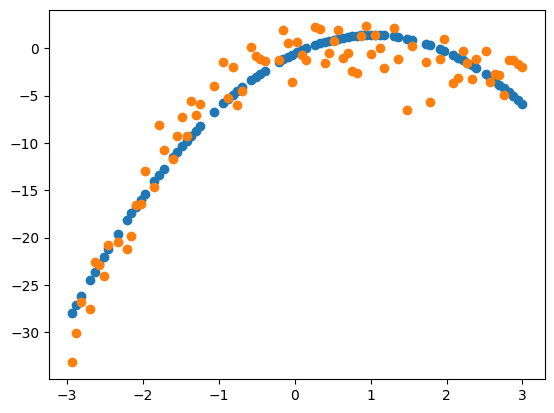

In [57]:
plt.scatter(X_train, model_poly.predict(X_train_poly))
plt.scatter(X_train, y_train)

### checking for degree 3

In [58]:
poly = PolynomialFeatures(degree=3, include_bias=True)
X_train_poly = poly.fit_transform(X_train.reshape(-1, 1))
X_test_poly = poly.transform(X_test.reshape(-1, 1))

In [59]:
X_train_poly[:5]  # Show the first 5 transformed samples

array([[ 1.        ,  0.33333333,  0.11111111,  0.03703704],
       [ 1.        ,  2.33333333,  5.44444444, 12.7037037 ],
       [ 1.        , -1.42424242,  2.02846648, -2.88902802],
       [ 1.        , -0.45454545,  0.20661157, -0.09391435],
       [ 1.        ,  1.18181818,  1.39669421,  1.65063862]])

In [62]:
degree_3_model = LinearRegression()

In [63]:
y_ply_pred = degree_3_model.fit(X_train_poly, y_train).predict(X_test_poly)
degree_3_score = r2_score(y_test, y_ply_pred)
print(f"Degree 3 Polynomial Regression R² Score: {degree_3_score:.4f}")


Degree 3 Polynomial Regression R² Score: 0.9759


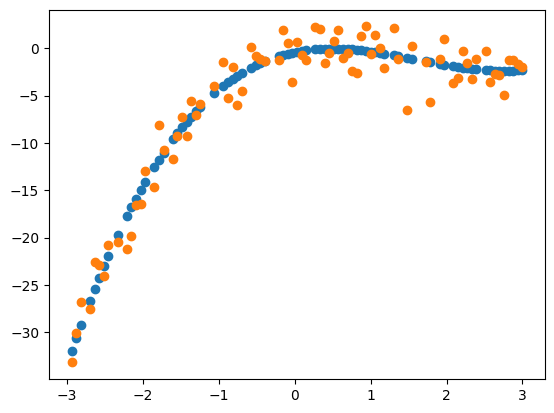

In [65]:
plt.scatter(X_train, degree_3_model.predict(X_train_poly))
plt.scatter(X_train, y_train)


### Inferencing

In [71]:
## prediction on new data
X_new = np.linspace(-3, 3, 200).reshape(-1, 1)  # New data points for prediction
X_new_poly = poly.transform(X_new)  # Transform new data to polynomial features
# X_new_poly

In [67]:
y_new_pred = degree_3_model.predict(X_new_poly)  # Predict using the degree 3 model

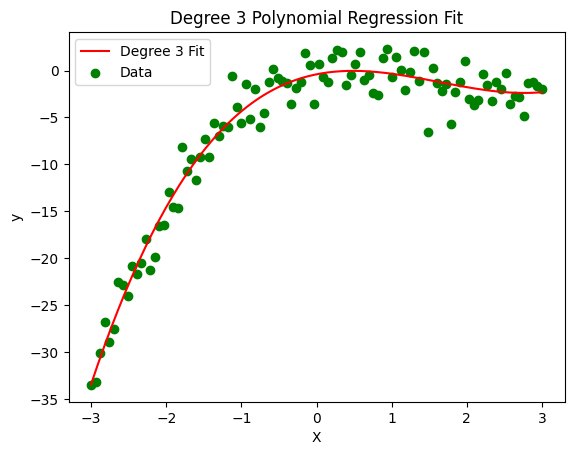

In [70]:
plt.plot(X_new, y_new_pred, color='red', label='Degree 3 Fit')
plt.scatter(X, y, color='green', label='Data')
plt.xlabel('X')
plt.ylabel('y')     
plt.title('Degree 3 Polynomial Regression Fit')
plt.legend()
plt.show()  

### Pipeline

In [72]:
from sklearn.pipeline import Pipeline

In [86]:
def polynomial_regression_pipeline(degree):
    
    X_new = np.linspace(-3, 3, 200).reshape(-1, 1)  # New data points for prediction
    poly_regression =  Pipeline([
        ('poly_features', PolynomialFeatures(degree=degree, include_bias=True)),
        ('linear_model', LinearRegression())
    ])
    y_pred_new = poly_regression.fit(X_train.reshape(-1, 1), y_train)
    y_pred_new = poly_regression.predict(X_new)
    
    # Plotting predictions line
    plt.scatter(X_new, y_pred_new, color='red', label=f'Degree {degree} Fit')
    plt.scatter(X_train,y_train, color='blue', label='Data', linewidth=3, marker='o')
    plt.scatter(X_test,y_test, color='green', label='Test Data', linewidth=3, marker='x')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title(f'Degree {degree} Polynomial Regression Fit')
    plt.legend(loc='upper left')
    plt.show()

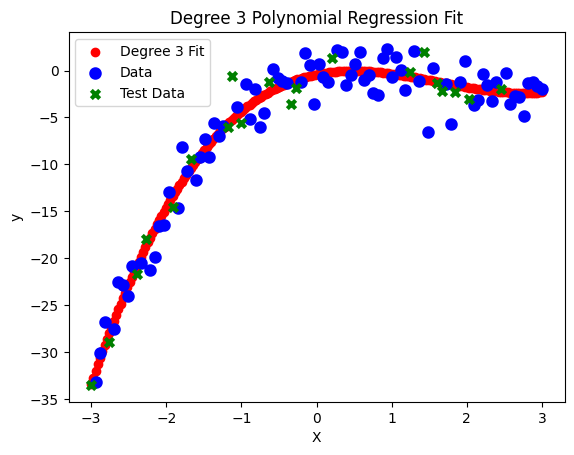

In [87]:
polynomial_regression_pipeline(degree=3)